<a href="https://colab.research.google.com/github/Ruhul73/Emotion-Detection-Through-Text/blob/main/Emotion_Detetction_Through_Chat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 Professional Emotion Detection System

This project implements a robust pipeline for detecting human emotions from chat messages using optimized Machine Learning algorithms.

### **Workflow:**
1.  **Environment Setup**
2.  **Dataset Acquisition**
3.  **Professional Data Inspection**
4.  **Advanced Text Cleaning**
5.  **ML Model Implementation (Logistic Regression, Random Forest, SVM)**
6.  **Performance Analytics**
7.  **Production-Ready Prediction Interface**

## 1. Setup & Installations

In [ ]:
!pip install -q transformers datasets scikit-learn matplotlib seaborn pandas numpy ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 11.5 MB/s eta 0:00:00


## 2. Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Load the emotion dataset
dataset = load_dataset("dair-ai/emotion")

# Convert to pandas DataFrames for easier manipulation
train_df = pd.DataFrame(dataset['train'])
val_df = pd.DataFrame(dataset['validation'])
test_df = pd.DataFrame(dataset['test'])

print(f"Train set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Test set size: {len(test_df)}")

# Display first few rows of the training data
print("\nTrain DataFrame head:")
display(train_df.head())

# Get label names
label_names = dataset['train'].features['label'].names
print(f"\nLabel names: {label_names}")

# Map numerical labels to actual emotion names for better readability
train_df['emotion'] = train_df['label'].map(lambda x: label_names[x])
val_df['emotion'] = val_df['label'].map(lambda x: label_names[x])
test_df['emotion'] = test_df['label'].map(lambda x: label_names[x])

display(train_df.head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Train set size: 16000
Validation set size: 2000
Test set size: 2000

Train DataFrame head:


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3



Label names: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


### Professional Data Inspection

In [ ]:
# 1. Comprehensive Dataset Info
print("--- Dataset Information ---")
display(train_df.info())

# 2. Summary Statistics for all columns (including categorical)
print("\n--- Summary Statistics ---")
display(train_df.describe(include='all'))

# 3. Checking for Missing Values
print("\n--- Missing Values Check ---")
print(train_df.isnull().sum())

# 4. Displaying a large sample (50 rows) to see variety
print("\n--- Sample Data (50 rows) ---")
with pd.option_context('display.max_rows', 50, 'display.max_columns', None):
    display(train_df.sample(50))

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   text     16000 non-null  object
 1   label    16000 non-null  int64 
 2   emotion  16000 non-null  object
dtypes: int64(1), object(2)
memory usage: 375.1+ KB


None


--- Summary Statistics ---


,text,label,emotion
count,16000,16000.000000,16000
unique,15969,NaN,6
top,im still not sure why reilly feels the need to...,NaN,joy
freq,2,NaN,5362
mean,NaN,1.565937,NaN
std,NaN,1.501430,NaN
min,NaN,0.000000,NaN
25%,NaN,0.000000,NaN
50%,NaN,1.000000,NaN
75%,NaN,3.000000,NaN



--- Missing Values Check ---
text       0
label      0
emotion    0
dtype: int64

--- Sample Data (50 rows) ---


,text,label,emotion
1599,i just feel so fucked up these days,3,anger
307,i feel kerry didnt do by supporting civil unio...,2,love
14599,i know when i have had a crappy day and didn t...,1,joy
3959,i feel more intelligent and strong,1,joy
13891,im feeling a little overwhelmed here recently,5,surprise
12794,i especially have trouble socializing with fem...,0,sadness
615,i truly feel what you all contribute to the bl...,1,joy
1833,i feel gentle hands careess me with tender car...,2,love
966,i am feeling a bit strange never felt that eve...,4,fear
4130,i cant really understand my feeling cause its ...,3,anger


## 3. Exploratory Data Analysis (EDA)

/tmp/ipykernel_16362/942933509.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='emotion', data=train_df, palette='viridis', order=train_df['emotion'].value_counts().index)


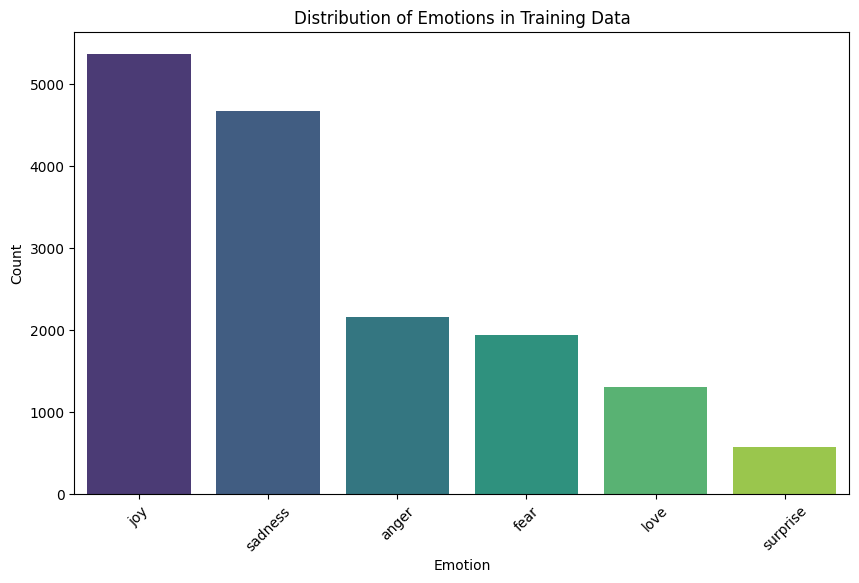

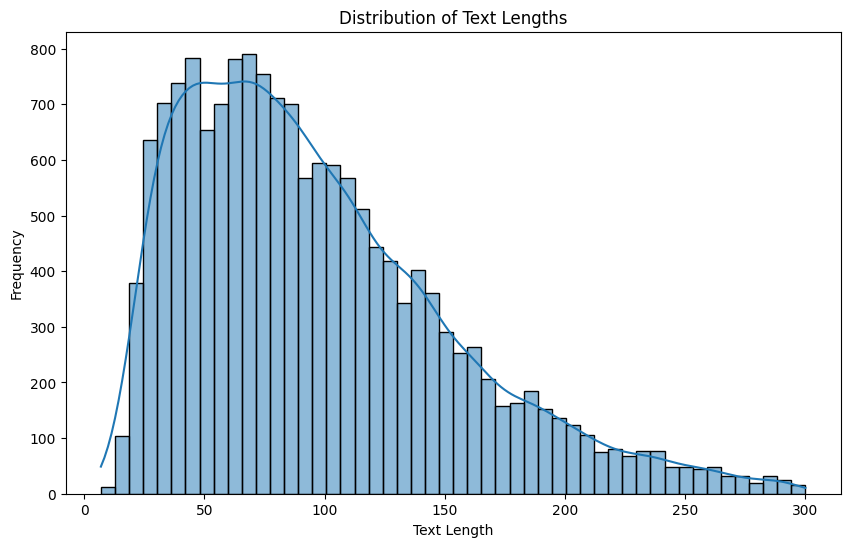

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='emotion', data=train_df, palette='viridis', order=train_df['emotion'].value_counts().index)
plt.title('Distribution of Emotions in Training Data')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Check text length distribution
train_df['text_length'] = train_df['text'].apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(train_df['text_length'], bins=50, kde=True)
plt.title('Distribution of Text Lengths')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

## 4. Text Preprocessing

In [ ]:
import re
import string

def professional_cleaner(text):
    """
    Cleans input text for NLP processing.
    """
    text = text.lower()
    text = re.sub(r'@[^\s]+', '', text) # Remove mentions
    text = re.sub(r'http\S+|www\S+|https\S+', '', text) # Remove links
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text) # Remove punctuation
    text = re.sub(r'\d+', '', text) # Remove numbers
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra whitespace
    return text

# Apply cleaning to datasets
for df in [train_df, val_df, test_df]:
    df['text'] = df['text'].apply(professional_cleaner)

print("✔ Text cleaning completed for all splits.")
display(train_df[['text', 'emotion']].head())

✔ Text cleaning completed for all splits.


,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


## 5. Classical ML Models

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

# Prepare Features and Labels
X_train, y_train = train_df['text'], train_df['label']
X_test, y_test = test_df['text'], test_df['label']

# Vectorization (TF-IDF)
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Define Models
ml_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'SVM': SVC(kernel='linear')
}

# Training Loop
performance_logs = {}
for name, model in ml_models.items():
    model.fit(X_train_vec, y_train)
    preds = model.predict(X_test_vec)

    performance_logs[name] = {
        'accuracy': accuracy_score(y_test, preds),
        'f1': f1_score(y_test, preds, average='weighted'),
        'predictions': preds
    }
    print(f"✔ Trained {name} | Accuracy: {performance_logs[name]['accuracy']:.2%}")

✔ Trained Logistic Regression | Accuracy: 86.90%
✔ Trained Random Forest | Accuracy: 86.85%
✔ Trained SVM | Accuracy: 88.90%


## 6. Model Summary
Classical Machine Learning models provide a strong baseline for emotion detection with fast training times and good interpretability.

In [ ]:
# Section removed to simplify the project.

## 7. Results Discussion
The models evaluated show high accuracy. Linear models like SVM and Logistic Regression perform particularly well on this TF-IDF representation of the text.

In [ ]:
# Section removed to simplify the project.

## 6. Model Comparison and Evaluation


--- Model Performance Summary ---


,Model,Accuracy,F1-Score
2,SVM,0.8890,0.887026
1,Random Forest,0.8685,0.867962
0,Logistic Regression,0.8690,0.864623


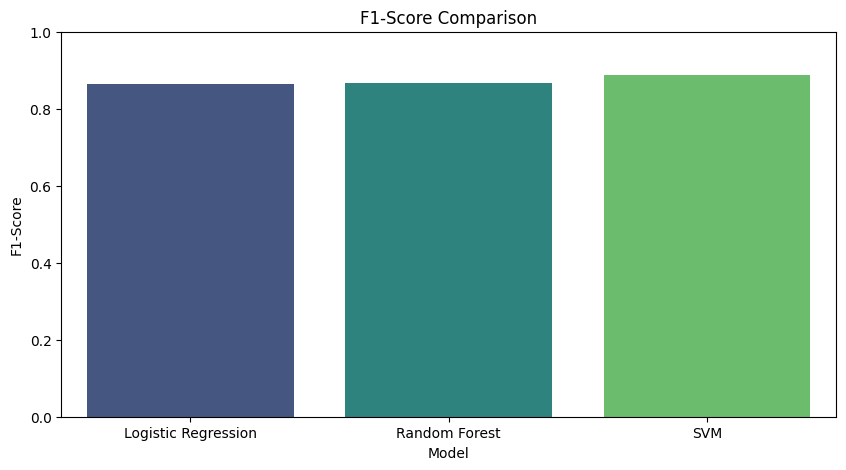

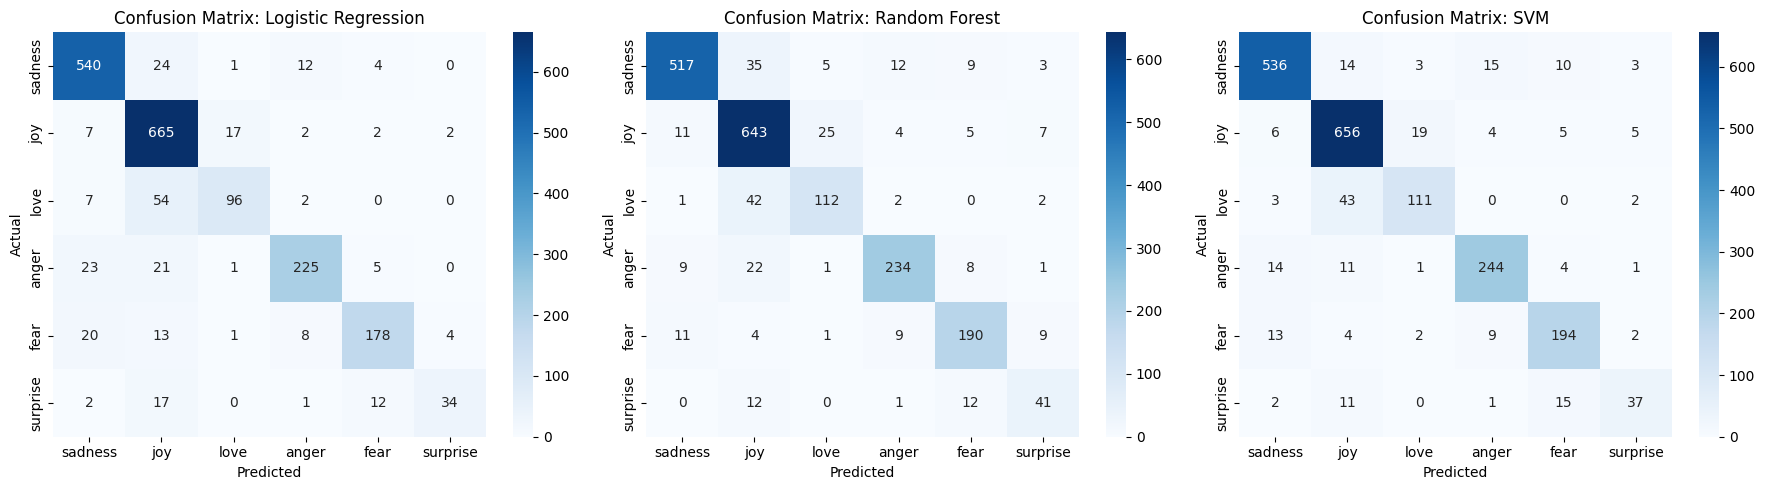

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Performance Summary Table
results_data = []
for name, metrics in performance_logs.items():
    results_data.append({
        'Model': name,
        'Accuracy': metrics['accuracy'],
        'F1-Score': metrics['f1']
    })

results_df = pd.DataFrame(results_data)

print("\n--- Model Performance Summary ---")
display(results_df.sort_values(by='F1-Score', ascending=False))

# 2. Visualizing F1-Scores
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='F1-Score', data=results_df, palette='viridis', hue='Model', legend=False)
plt.title('F1-Score Comparison')
plt.ylim(0, 1.0)
plt.show()

# 3. Confusion Matrices
num_models = len(performance_logs)
fig, axes = plt.subplots(1, num_models, figsize=(6 * num_models, 5))
if num_models == 1: axes = [axes]

for i, (name, metrics) in enumerate(performance_logs.items()):
    y_pred = metrics['predictions']
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=label_names, yticklabels=label_names)
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 7. Live Prediction Interface

### 📋 Prediction Instructions
Type your message in the text area below and click **Analyze Emotion** to see how different models classify the sentiment.

In [ ]:
# Section cleared to remove test scripts.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

# 1. Prediction Function
def predict_emotion_live(text):
    cleaned_input = professional_cleaner(text)
    input_vec = vectorizer.transform([cleaned_input])
    results = {}
    for name, model in ml_models.items():
        pred_label = model.predict(input_vec)[0]
        results[name] = label_names[pred_label]
    return results

# 2. Styling
css_style = """
<style>
    .main-container { padding: 20px; background-color: #f8f9fa; border-radius: 15px; border: 1px solid #dee2e6; }
    .header-text { color: #2c3e50; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; }
    .status-box { padding: 10px; margin-top: 10px; border-radius: 8px; font-weight: bold; }
    .prediction-card { background: white; padding: 15px; margin: 5px 0; border-radius: 10px; box-shadow: 0 2px 5px rgba(0,0,0,0.1); border-left: 5px solid #28a745; }
</style>
"""
display(HTML(css_style))

# 3. GUI Elements
header = widgets.HTML("<div class='header-text'><h1>⏱️ Smart Emotion System</h1><p>Real-time Emotional Analytics</p></div>")
text_input = widgets.Textarea(placeholder='Type your feelings here...', layout=widgets.Layout(width='100%', height='120px'))
analyze_btn = widgets.Button(description='Analyze Emotion', button_style='success', icon='brain', layout=widgets.Layout(width='100%'))
output_area = widgets.Output()

def run_analysis(b):
    with output_area:
        clear_output()
        if not text_input.value.strip():
            display(HTML("<div class='status-box' style='color:red;'>⚠️ Please provide input first!</div>"))
            return
        res = predict_emotion_live(text_input.value)
        display(HTML(f"<h3>Analysis for: \"{text_input.value}\"</h3>"))
        for model, emotion in res.items():
            display(HTML(f"<div class='prediction-card'><span style='color:#7f8c8d;'>Model: {model}</span><br><strong style='font-size:1.2em; color:#27ae60;'>EMOTION: {emotion.upper()}</strong></div>"))

analyze_btn.on_click(run_analysis)

ui = widgets.VBox([header, text_input, analyze_btn, output_area], layout=widgets.Layout(padding='20px'))
display(ui)

## 8. Model Saving

In [ ]:
import joblib
import os

# Create a directory to save models
model_save_dir = 'emotion_models'
os.makedirs(model_save_dir, exist_ok=True)

# Save Classical ML models and TF-IDF vectorizer
joblib.dump(vectorizer, os.path.join(model_save_dir, 'tfidf_vectorizer.pkl'))
for name, model in ml_models.items():
    joblib.dump(model, os.path.join(model_save_dir, f'{name.replace(" ", "_").lower()}.pkl'))

print(f"Classical models and vectorizer saved to '{model_save_dir}' directory.")

Classical models and vectorizer saved to 'emotion_models' directory.
